In [29]:
import torch
import torch.nn as nn
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader,TensorDataset

In [30]:
df = pd.read_csv("train.csv")

In [31]:
df.drop("id",axis=1,inplace=True)

In [32]:
df.head(2)

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,female,64,163.0,60.0,8.0,85.0,39.7,34.0


In [33]:
df["Sex"] = pd.get_dummies(df["Sex"],drop_first=True,dtype="int")

In [34]:
df.head(2)

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,1,36,189.0,82.0,26.0,101.0,41.0,150.0
1,0,64,163.0,60.0,8.0,85.0,39.7,34.0


In [35]:
x = df.drop("Calories",axis=1).values

In [36]:
x

array([[  1. ,  36. , 189. , ...,  26. , 101. ,  41. ],
       [  0. ,  64. , 163. , ...,   8. ,  85. ,  39.7],
       [  0. ,  51. , 161. , ...,   7. ,  84. ,  39.8],
       ...,
       [  1. ,  60. , 162. , ...,  29. , 113. ,  40.9],
       [  1. ,  45. , 182. , ...,  17. , 102. ,  40.3],
       [  0. ,  39. , 171. , ...,  19. ,  97. ,  40.6]])

In [37]:
y = df["Calories"].values

In [38]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [39]:
scaler1 = StandardScaler()
x_train = scaler1.fit_transform(x_train)
x_test = scaler1.transform(x_test)

In [40]:
scaler2 = StandardScaler()
y_train = scaler2.fit_transform(y_train.reshape(-1,1))
y_test = scaler2.transform(y_test.reshape(-1,1))

In [41]:
joblib.dump(scaler1,filename=r"simple_ann_files/x_train_x_test_scaler.pkl")
joblib.dump(scaler2,filename=r"simple_ann_files/y_train_y_test_scaler.pkl")

['simple_ann_files/y_train_y_test_scaler.pkl']

In [42]:
x_train = torch.tensor(x_train,dtype=torch.float32)
x_test = torch.tensor(x_test,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

In [43]:
train_dataset = TensorDataset(
    x_train,
    y_train
)

test_dataset = TensorDataset(
    x_test,
    y_test
)

In [44]:
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=100
)

test_loader = DataLoader(
    test_dataset,
    shuffle=True,
    batch_size=100
)

In [17]:
class MyAnnModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.modellayer = nn.Sequential(
            nn.Linear(7,128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128,64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(64,32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32,1)
        )
    def forward(self,x):
        x = self.modellayer(x)
        return x



In [18]:
model = MyAnnModel()

In [19]:
model

MyAnnModel(
  (modellayer): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [23]:
loss_function = nn.MSELoss()
optimizer_function = torch.optim.AdamW(
    model.parameters(),
    lr=0.01,
    weight_decay=1.0
)

In [21]:
train_loss_hist = []
test_loss_hist = []

epochs = 20
process_bar = tqdm(range(epochs),colour="blue")

for epoch in process_bar:
    model.train()
    total_train_loss = 0
    for batch_train_x,batch_train_y in train_loader:
        optimizer_function.zero_grad()
        prediction = model(batch_train_x)
        loss = loss_function(prediction,batch_train_y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(),
                                 max_norm=1.0)
        optimizer_function.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for batch_x_test,batch_y_test in test_loader:
            test_prediction = model(batch_x_test)
            test_loss = loss_function(test_prediction,batch_y_test)
            total_test_loss += test_loss.item()
        avg_test_loss = total_test_loss / len(test_loader)

        train_loss_hist.append(avg_train_loss)
        test_loss_hist.append(avg_test_loss)

        torch.save({
            "Epoch":epoch,
            "Train Loss":avg_train_loss,
            "Test Loss":avg_test_loss,
            "Optimizer":optimizer_function.state_dict()
        },f"model_4/checkpoints_{epoch+1}.pth")

        process_bar.set_postfix({
            "Epoch":epoch+1,
            "Train Loss":f"{avg_train_loss:.4f}",
            "Test Loss":f"{avg_test_loss:.4f}"
        })

100%|██████████| 20/20 [09:04<00:00, 27.23s/it, Epoch=20, Train Loss=0.0749, Test Loss=0.0249]


Text(0.5, 1.0, 'Simple ANN')

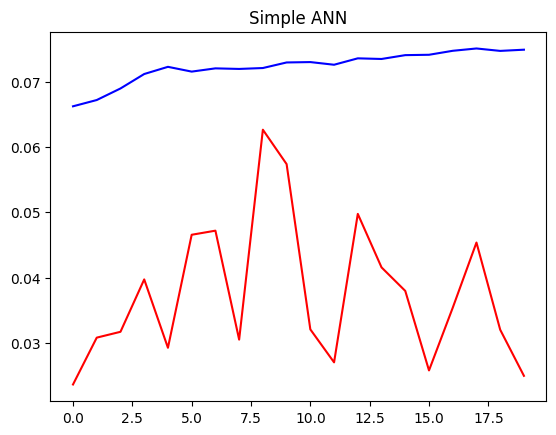

In [25]:
plt.plot(train_loss_hist,label="Train Loss",color="blue")
plt.plot(test_loss_hist,label="Test Loss",color="red")
plt.title("Simple ANN")

## Residual Block model

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.fc1 = nn.Linear(dim,dim)
        self.ln1 = nn.LayerNorm(dim)
        
        self.fc2 = nn.Linear(dim,dim)
        self.ln2 = nn.LayerNorm(dim)

        self.relu = nn.ReLU()

    def forward(self,x):
        identity = x
        out = self.fc1(x)
        out = self.ln1(out)
        out = self.relu(out)

        out = self.fc2(out)
        out = self.ln2(out)

        out = out + identity

        out = self.relu(out)

        return out
    
class MyModel(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim,128),
            nn.LayerNorm(128),
            nn.ReLU()
        )

        self.re1 = ResidualBlock(128)
        self.re2 = ResidualBlock(128)

        self.output = nn.Linear(128,1)
    
    def forward(self,x):
        x = self.input_layer(x)

        x = self.re1(x)
        x = self.re2(x)

        x = self.output(x)

        return x

In [22]:
model = MyModel(input_dim=7)

In [24]:
train_loss_hist = []
test_loss_hist = []

epochs = 20
process_bar = tqdm(range(epochs),colour="blue")

for epoch in process_bar:
    model.train()
    total_train_loss = 0
    for batch_train_x,batch_train_y in train_loader:
        optimizer_function.zero_grad()
        prediction = model(batch_train_x)
        loss = loss_function(prediction,batch_train_y)
        loss.backward()
        #nn.utils.clip_grad_norm_(model.parameters(),
         #                        max_norm=1.0)
        optimizer_function.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for batch_x_test,batch_y_test in test_loader:
            test_prediction = model(batch_x_test)
            test_loss = loss_function(test_prediction,batch_y_test)
            total_test_loss += test_loss.item()
        avg_test_loss = total_test_loss / len(test_loader)

        train_loss_hist.append(avg_train_loss)
        test_loss_hist.append(avg_test_loss)

        torch.save({
            "Epoch":epoch,
            "Train Loss":avg_train_loss,
            "Test Loss":avg_test_loss,
            "Optimizer":optimizer_function.state_dict()
        },f"model_5/checkpoints_{epoch+1}.pth")

        process_bar.set_postfix({
            "Epoch":epoch+1,
            "Train Loss":f"{avg_train_loss:.4f}",
            "Test Loss":f"{avg_test_loss:.4f}"
        })

100%|██████████| 20/20 [24:27<00:00, 73.39s/it, Epoch=20, Train Loss=0.0313, Test Loss=0.0250]


Text(0.5, 1.0, 'Residual ANN')

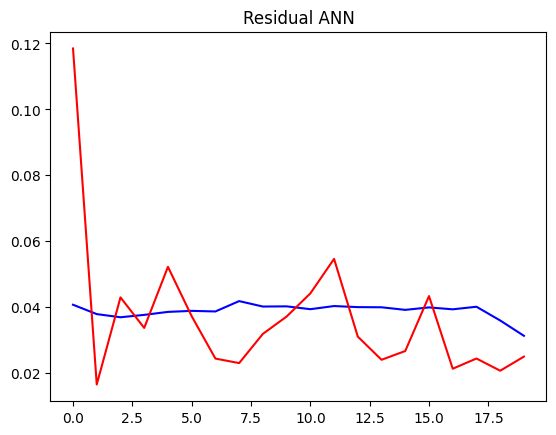

In [25]:
plt.plot(train_loss_hist,label="Train Loss",color="blue")
plt.plot(test_loss_hist,label="Test Loss",color="red")
plt.title("Residual ANN")

## without clip gradient

In [45]:
class ResidualBlock(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.fc1 = nn.Linear(dim,dim)
        self.ln1 = nn.LayerNorm(dim)
        
        self.fc2 = nn.Linear(dim,dim)
        self.ln2 = nn.LayerNorm(dim)

        self.relu = nn.ReLU()

    def forward(self,x):
        identity = x
        out = self.fc1(x)
        out = self.ln1(out)
        out = self.relu(out)

        out = self.fc2(out)
        out = self.ln2(out)

        out = out + identity

        out = self.relu(out)

        return out
    
class MyModel(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim,128),
            nn.LayerNorm(128),
            nn.ReLU()
        )

        self.re1 = ResidualBlock(128)
        self.re2 = ResidualBlock(128)

        self.output = nn.Linear(128,1)
    
    def forward(self,x):
        x = self.input_layer(x)

        x = self.re1(x)
        x = self.re2(x)

        x = self.output(x)

        return x

In [47]:
model = MyModel(7)

In [48]:
loss_function = nn.MSELoss()
optimizer_function = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1.0
)

In [49]:
train_loss_hist = []
test_loss_hist = []

epochs = 20
process_bar = tqdm(range(epochs),colour="blue")

for epoch in process_bar:
    model.train()
    total_train_loss = 0
    for batch_train_x,batch_train_y in train_loader:
        optimizer_function.zero_grad()
        prediction = model(batch_train_x)
        loss = loss_function(prediction,batch_train_y)
        loss.backward()
        #nn.utils.clip_grad_norm_(model.parameters(),
         #                        max_norm=1.0)
        optimizer_function.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for batch_x_test,batch_y_test in test_loader:
            test_prediction = model(batch_x_test)
            test_loss = loss_function(test_prediction,batch_y_test)
            total_test_loss += test_loss.item()
        avg_test_loss = total_test_loss / len(test_loader)

        train_loss_hist.append(avg_train_loss)
        test_loss_hist.append(avg_test_loss)

        torch.save({
            "Epoch":epoch,
            "Train Loss":avg_train_loss,
            "Test Loss":avg_test_loss,
            "Optimizer":optimizer_function.state_dict()
        },f"model_6/checkpoints_{epoch+1}.pth")

        process_bar.set_postfix({
            "Epoch":epoch+1,
            "Train Loss":f"{avg_train_loss:.4f}",
            "Test Loss":f"{avg_test_loss:.4f}"
        })

100%|██████████| 20/20 [11:43<00:00, 35.17s/it, Epoch=20, Train Loss=0.0090, Test Loss=0.0073]


Text(0.5, 1.0, 'Residual ANN without cliping')

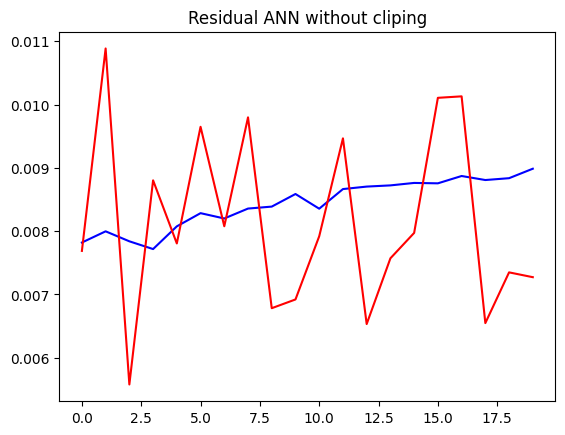

In [50]:
plt.plot(train_loss_hist,label="Train Loss",color="blue")
plt.plot(test_loss_hist,label="Test Loss",color="red")
plt.title("Residual ANN without cliping")

In [51]:
model.eval()

MyModel(
  (input_layer): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
  )
  (re1): ResidualBlock(
    (fc1): Linear(in_features=128, out_features=128, bias=True)
    (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (fc2): Linear(in_features=128, out_features=128, bias=True)
    (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (relu): ReLU()
  )
  (re2): ResidualBlock(
    (fc1): Linear(in_features=128, out_features=128, bias=True)
    (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (fc2): Linear(in_features=128, out_features=128, bias=True)
    (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (relu): ReLU()
  )
  (output): Linear(in_features=128, out_features=1, bias=True)
)

In [52]:
with torch.no_grad():
    pred = []
    actual = []
    for batch_x_d,batch_y_d in test_loader:
        prediction = model(batch_x_d)
        pred.extend(prediction.squeeze().numpy())
        actual.extend(batch_y_d.numpy())

In [55]:
pred = scaler2.inverse_transform(np.array(pred).reshape(-1,1))
actual = scaler2.inverse_transform(np.array(actual).reshape(-1,1))

mse = mean_squared_error(actual, pred)
mae = mean_absolute_error(actual, pred)
r2 = r2_score(actual, pred)

In [56]:
pred

array([[37.90827 ],
       [60.469765],
       [55.368656],
       ...,
       [50.635937],
       [76.71086 ],
       [27.447582]], dtype=float32)

In [57]:
mse = mean_squared_error(actual,pred)**0.5
mae = mean_absolute_error(actual,pred)
r2 = r2_score(actual,pred)

In [58]:
print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2: {r2}")

MSE: 5.324035507037889
MAE: 3.460671901702881
R2: 0.9926862120628357


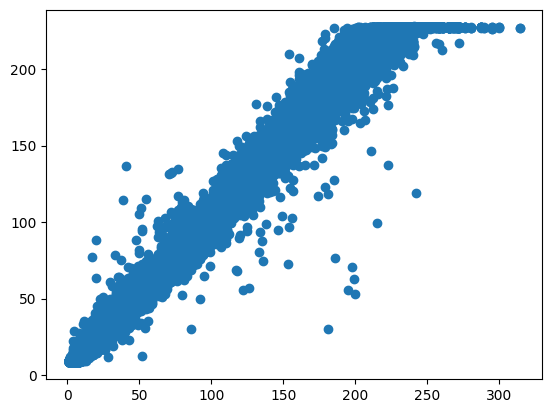

In [61]:
plt.scatter(actual,pred,colorizer="blue")

In [63]:
model.eval()

train_pred = []
train_actual = []

with torch.no_grad():

    for X_batch, y_batch in train_loader:

        outputs = model(X_batch)

        train_pred.extend(outputs.cpu().numpy())
        train_actual.extend(y_batch.cpu().numpy())

train_r2 = r2_score(train_actual, train_pred)
train_mae = mean_absolute_error(train_actual, train_pred)
train_rmse = mean_squared_error(train_actual, train_pred) ** 0.5

print("===== TRAIN =====")
print("R2   :", train_r2)
print("MAE  :", train_mae)
print("RMSE :", train_rmse)

===== TRAIN =====
R2   : 0.9924860801032472
MAE  : 0.05567871098271416
RMSE : 0.08668286967828545


In [66]:
model.eval()

test_pred = []
test_actual = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        outputs = model(X_batch)

        test_pred.extend(outputs.cpu().numpy())
        test_actual.extend(y_batch.cpu().numpy())

test_r2 = r2_score(test_actual, test_pred)
test_mae = mean_absolute_error(test_actual, test_pred)
test_rmse = mean_squared_error(test_actual, test_pred) ** 0.5

print("===== TEST =====")
print("R2   :", test_r2)
print("MAE  :", test_mae)
print("RMSE :", test_rmse)

===== TEST =====
R2   : 0.9926862322502441
MAE  : 0.05543242569216217
RMSE : 0.08527944573891257


In [68]:
print("Duplicate Rows:", df.duplicated().sum() / len(df) * 100)

Duplicate Rows: 0.3788


In [69]:
print("Duplicate %:", df.duplicated().sum()/len(df)*100)

Duplicate %: 0.3788
